# Capstone A — FreshMart Retail Chain: Sales Intelligence Pipeline
**Python for Full Stack Data Science with AI & Generative AI · Naresh IT · Lead Trainer: Ajit Byru**

**The client.** Five supermarkets, one owner, a daily total per store and nothing else. Twelve promotions this year; nobody knows if any worked. She wants one tool she can run every month.

**What this notebook does.** It *imports your package* — nothing is cleaned or computed here that isn't a function in `freshmart/`. The notebook is the findings; the package is the product.

**Rules:** no `sklearn`; every cleaning rule is a function that writes to the `QualityLog`; the CLI must run; fresh-kernel run before submission.

---
## Session 1 — Load, validate, clean (through the package)

### 1.1 Load with validation
`SalesLoader` raises `DataFileError` if a file is missing and `SchemaError` if columns are missing. Prove both exceptions work before trusting the loader.

In [2]:
from freshmart import SalesLoader, DataFileError, SchemaError, QualityLog, clean_sales
from freshmart.cleaner import clean_products
from freshmart.report import top_margin, promo_lift, patterns, stockouts, store_productivity
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
loader = SalesLoader("data"); d = loader.load_all()
print({k: v.shape for k, v in d.items()})

{'sales': (40284, 7), 'products': (120, 6), 'stores': (5, 5), 'promotions': (12, 6)}


In [3]:
# YOUR CODE HERE
# Hint: try: SalesLoader('no_such_folder') except DataFileError; then a folder with a bad sales file -> SchemaError
from pathlib import Path

# Test 1: missing folder
try:
    SalesLoader("no_such_folder")
except DataFileError:
    print("DataFileError caught")

# Test 2: bad sales file columns
Path("bad_dir").mkdir(exist_ok=True)
pd.DataFrame({"wrong": [1]}).to_csv("bad_dir/sales_2025.csv", index=False)
try:
    SalesLoader("bad_dir")._read("sales_2025.csv")
except SchemaError:
    print("SchemaError caught")
finally:
    Path("bad_dir/sales_2025.csv").unlink(missing_ok=True)
    Path("bad_dir").rmdir()

DataFileError caught
SchemaError caught


### 1.2 Profile the raw sales file
Before writing any cleaning rule, look. `info()`, `describe()`, nulls, duplicates, and the *type* of `unit_price`.

In [4]:
# YOUR CODE HERE
# Hint: info(), isna().sum(), duplicated().sum(), look at unit_price and sale_date samples, qty.min(), store_id val
sales = d["sales"]
sales.info()

sales.describe()

print(sales.isna().sum())

print("Duplicates:", sales.duplicated().sum())

print("Unit price type:", sales["unit_price"].dtype)
print("Unit price samples:")
print(sales["unit_price"].head())

print("Sale date samples:")
print(sales["sale_date"].head())

print("Minimum quantity:", sales["qty"].min())

print("Store IDs:")
print(sales["store_id"].unique())

<class 'pandas.DataFrame'>
RangeIndex: 40284 entries, 0 to 40283
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   receipt_id    40284 non-null  str    
 1   store_id      40284 non-null  int64  
 2   product_id    40284 non-null  int64  
 3   sale_date     40284 non-null  str    
 4   qty           40284 non-null  int64  
 5   unit_price    40284 non-null  str    
 6   discount_pct  39984 non-null  float64
dtypes: float64(1), int64(3), str(3)
memory usage: 2.2 MB
receipt_id        0
store_id          0
product_id        0
sale_date         0
qty               0
unit_price        0
discount_pct    300
dtype: int64
Duplicates: 150
Unit price type: str
Unit price samples:
0     22.0
1    159.0
2    352.0
3     70.0
4     66.0
Name: unit_price, dtype: str
Sale date samples:
0    2025-11-06
1    2025-04-25
2    2025-07-18
3    2025-02-23
4    2025-03-05
Name: sale_date, dtype: str
Minimum quantity: -6
Store IDs:
[3 4 

### 1.3 The generator
`stream_sales()` yields the file in chunks. Use it to count rows and sum `qty` **without loading the whole file** — then compare timing and memory with a plain `read_csv`.

In [5]:
# YOUR CODE HERE
# Hint: for chunk in loader.stream_sales(): rows += len(chunk) ... ; compare with pd.read_csv timing
import time

# Start timing the generator
start = time.time()

rows = 0
total_qty = 0

for chunk in loader.stream_sales():
    rows = rows + len(chunk)
    total_qty = total_qty + pd.to_numeric(
        chunk["qty"], errors="coerce"
    ).sum()

stream_time = time.time() - start

# Start timing normal read_csv
start = time.time()

df_plain = pd.read_csv("data/sales_2025.csv")

plain_time = time.time() - start

# Display results
print("Stream:", rows, "rows, qty", total_qty,
      "in", round(stream_time, 3), "seconds")

print("Plain:", len(df_plain), "rows, in",
      round(plain_time, 3), "seconds")

Stream: 40284 rows, qty 100832 in 0.073 seconds
Plain: 40284 rows, in 0.036 seconds


### 1.4 Clean through the package
`clean_products` then `clean_sales`. Everything they did is in the `QualityLog` — print it. This table is graded.

In [6]:
# YOUR CODE HERE
# Hint: log = QualityLog(); products = clean_products(...); sales = clean_sales(...); log.to_frame()
log = QualityLog()
products = clean_products(d["products"], log)
sales = clean_sales(d["sales"], products, d["stores"], log)
log.to_frame()

,problem,rows_affected,fix,why
0,product_name whitespace,3,Trim whitespace,Keep product names consistent
1,cost_price > unit_price,1,Flag margin_ok=False,Identify products with invalid margins
2,Duplicate sales,150,Remove duplicate rows,Avoid counting the same sale twice
3,unit_price text,2408,Convert to numeric,Allow price calculations
4,Invalid sale dates,0,Convert to datetime,Allow date-based analysis
5,Negative quantity,40,Replace with 0,Quantity cannot be negative
6,Unknown product_id,25,Remove unknown products,Keep only valid products
7,Unknown store_id,12,Remove unknown stores,Keep only valid stores
8,Missing discount_pct,300,Fill with 0,No discount means full price


**Your Data-Quality Log lives in the package.** Every rule you add to `cleaner.py` must call `log.add(problem, rows, fix, why)`. The stubs are there; the `why` column is graded.

### 1.5 Acceptance
Print the final shape and the sum of `revenue`. These are the numbers you compare with the trainer's.

In [7]:
# YOUR CODE HERE
# Hint: sales.shape, sales['revenue'].sum(), save sales_clean.csv
print("Sales shape:", sales.shape)
print("Total revenue:", sales["revenue"].sum())

sales.to_csv("data/sales_clean.csv", index=False)
print("sales_clean.csv saved successfully")

Sales shape: (40097, 9)
Total revenue: 10446460.0
sales_clean.csv saved successfully


---
## Session 2 — Questions 1–3

### Q1. Top products by **margin**, per store
Margin = (net price − cost) × qty. Revenue ranks the expensive; margin ranks the profitable. Do the top-10 lists differ between the biggest store and the smallest?

top_margin took 0.0129 seconds
top_margin took 0.0126 seconds
Store 4:
     product_id product_name    margin
45         1046      GROC-14  84889.08
92         1094      BEVE-12  61546.17
74         1076      SNAC-14  34554.74
48         1049      GROC-17  34002.00
108        1110      PERS-12  31964.10
43         1044      GROC-12  30344.51
107        1109      PERS-11  27485.71
16         1017      DAIR-17  26336.23
52         1053      GROC-21  21574.10
116        1118      HOUS-08  20985.36

Store 5:
     product_id product_name    margin
45         1046      GROC-14  40683.12
92         1094      BEVE-12  33417.72
48         1049      GROC-17  16660.98
74         1076      SNAC-14  15618.24
16         1017      DAIR-17  14611.84
43         1044      GROC-12  14317.20
108        1110      PERS-12  12815.10
52         1053      GROC-21  12613.30
107        1109      PERS-11  10922.66
116        1118      HOUS-08  10492.68

Common products:
{'GROC-12', 'GROC-21', 'GROC-17', 'PERS-11'

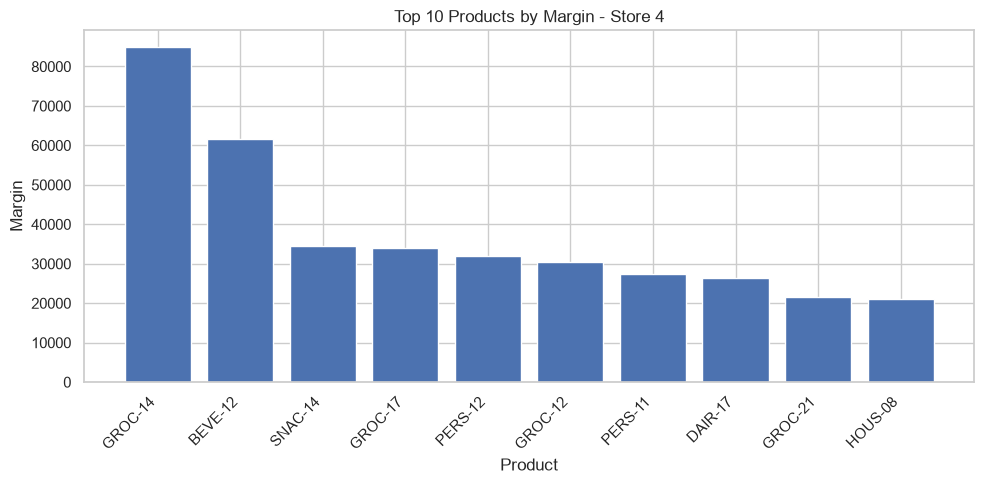

In [8]:
# YOUR CODE HERE
# Hint: top_margin(sales, products, store_id=4) vs store_id=5; set intersection of names; barplot
top_big = top_margin(sales, products, store_id=4)
top_small = top_margin(sales, products, store_id=5)

print("Store 4:")
print(top_big)

print("\nStore 5:")
print(top_small)

common = set(top_big["product_name"]) & set(top_small["product_name"])

print("\nCommon products:")
print(common)

plt.figure(figsize=(10, 5))
plt.bar(top_big["product_name"], top_big["margin"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Product")
plt.ylabel("Margin")
plt.title("Top 10 Products by Margin - Store 4")
plt.tight_layout()
plt.show()

*Reading:*

Store 4 and Store 5 have different top profitable products. Some products are common in both stores, while others are different. This shows that product profitability varies between stores.

### Q2. Did each promotion lift sales?
For each promotion: daily quantity during the 14 promo days vs the same weekdays in the 8 weeks before. A permutation test gives the p-value. **Reading:** which promotions worked, which didn't, and what do the ones that didn't have in common?

promo_lift took 0.3208 seconds


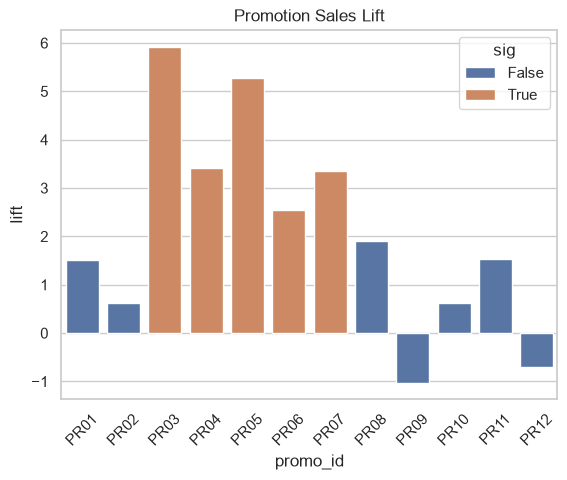

In [9]:
# YOUR CODE HERE
# Hint: promo_lift(sales, d['promotions']); bar chart coloured by p < 0.05
from freshmart.report import promo_lift
import seaborn as sns
import matplotlib.pyplot as plt

promo_results = promo_lift(sales, d["promotions"])

promo_results["sig"] = promo_results["p_value"] < 0.05

sns.barplot(
    data=promo_results,
    x="promo_id",
    y="lift",
    hue="sig"
)

plt.title("Promotion Sales Lift")
plt.xticks(rotation=45)
plt.show()

*Reading:*

PR03, PR04, PR05, PR06, and PR07 show a significant positive sales lift.

PR01, PR02, PR08, PR09, PR10, PR11, and PR12 are not statistically significant.

Overall, some promotions increased sales clearly, while others showed little or no clear impact.

### Q3. Weekday and monthly patterns per category
Two heatmaps. **Reading:** where does the weekend peak sit, and does the perishable category (Dairy, Bakery) behave differently?

patterns took 0.0599 seconds


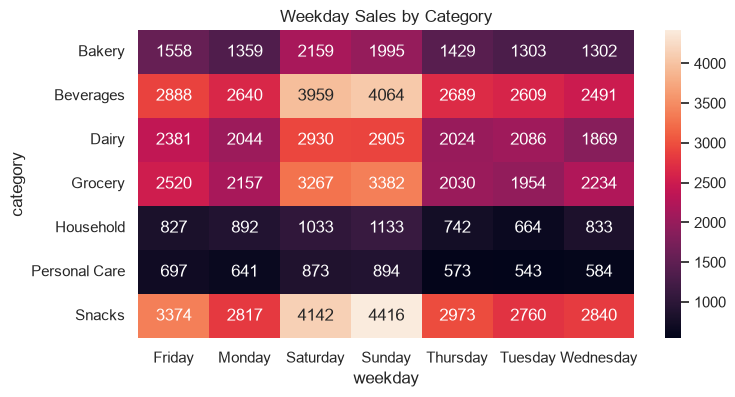

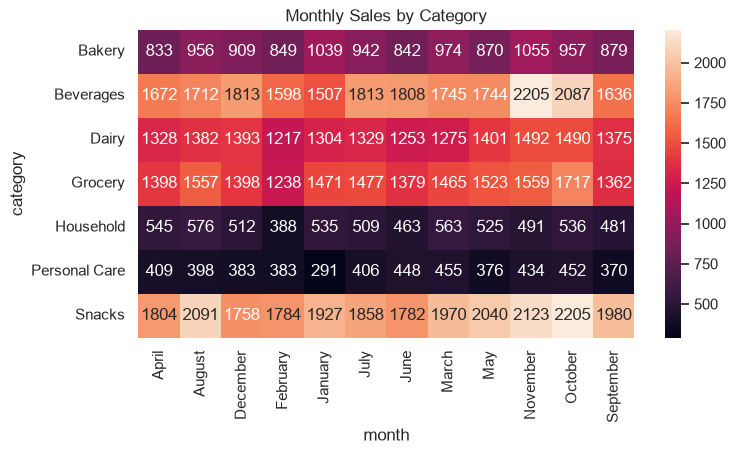

In [10]:
# YOUR CODE HERE
# Hint: wd, mo = patterns(sales, products); two heatma
from freshmart.report import patterns
from freshmart import SalesLoader

sales = pd.read_csv("data/sales_clean.csv")

products = pd.read_csv("data/products.csv")

wd, mo = patterns(sales, products)

plt.figure(figsize=(8, 4))
sns.heatmap(wd, annot=True, fmt=".0f")
plt.title("Weekday Sales by Category")
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(mo, annot=True, fmt=".0f")
plt.title("Monthly Sales by Category")
plt.show()

*Reading:*

---
## Session 3 — Questions 4–6, CLI, recommendation

### Q4. Stock-outs
A product-store pair that normally sells several times a day and then shows zero for 6+ consecutive days. **Reading:** how much revenue did each stock-out cost (average daily revenue × days)?

In [11]:
# YOUR CODE HERE
# Hint: stockouts(sales); revenue lost = avg daily revenue x zero days
from freshmart.report import stockouts

so = stockouts(sales)
so["revenue_lost"] = (
    so["avg_daily_revenue"] * so["max_zero_run"]
)
print("Total revenue lost:", so["revenue_lost"].sum())

so.head()

stockouts took 2.2539 seconds
Total revenue lost: 28440.59525754632


,product_id,store_id,rate,max_zero_run,avg_daily_revenue,revenue_lost
0,1032,3,2.419890,6,152.237569,913.425414
1,1044,1,1.728022,7,212.500000,1487.500000
2,1044,3,1.626374,10,203.571429,2035.714286
3,1044,4,2.180822,6,271.753425,1630.520548
4,1046,2,2.030137,6,572.960000,3437.760000


*Reading:*

Some products were out of stock for 6 or more days in a row. We estimated how much money was lost during those stock-out days.

### Q5. Most profitable store per square foot
Floor area is the owner's scarcest resource. Rank by margin per sq ft, not revenue.

store_productivity took 0.0254 seconds
   store_id    revenue     margin  receipts               store_name  \
0         1  1717477.0  467755.45      6476  FreshMart Banjara Hills   
1         2  2491452.9  668620.50      9422     FreshMart Kukatpally   
2         3  1917148.0  519816.63      7275   FreshMart Secunderabad   
3         4  2855218.1  770276.59     11119     FreshMart Gachibowli   
4         5  1465164.0  398615.48      5805   FreshMart Dilsukhnagar   

   floor_area_sqft  margin_per_sq_ft  
0             4200        111.370345  
1             6800         98.326544  
2             5100        101.924829  
3             7500        102.703545  
4             3900        102.209097  


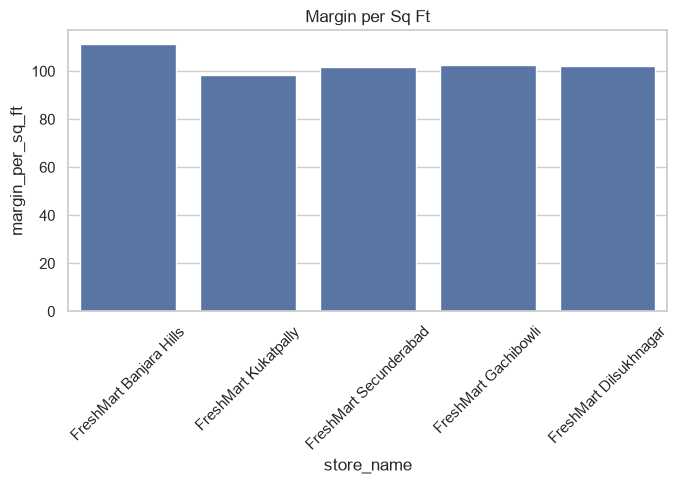

In [24]:
# YOUR CODE HERE
# Hint: store_productivity(sales, products, d['stores'])
from freshmart.report import store_productivity

productivity = store_productivity(sales,products, d["stores"])
print(productivity)

plt.figure(figsize=(7, 5))
sns.barplot(data=productivity, x="store_name", y="margin_per_sq_ft")
plt.title("Margin per Sq Ft")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Reading:*

It shows which store makes more profit from its available space. Higher margin per sq ft means better use of space.

### Q6. Your own question
Pick one: discount depth vs lift (do 25% promos beat 10%?) · category mix per store · the Oct–Nov festival effect · returns (the negative-qty rows) by product · receipts per day trend.

   promo_id  discount_pct      lift   p_value
0      PR01            10  1.508571  0.287712
1      PR02            15  0.614035  0.707293
2      PR03            10  5.927126  0.001998
3      PR04            25  3.420779  0.049950
4      PR05            10  5.285714  0.000999
5      PR06            10  2.540070  0.017982
6      PR07            20  3.360000  0.008991
7      PR08            25  1.902778  0.063936
8      PR09            15 -1.022876  0.349650
9      PR10            10  0.616162  0.681319
10     PR11            10  1.533333  0.201798
11     PR12            25 -0.706687  0.698302


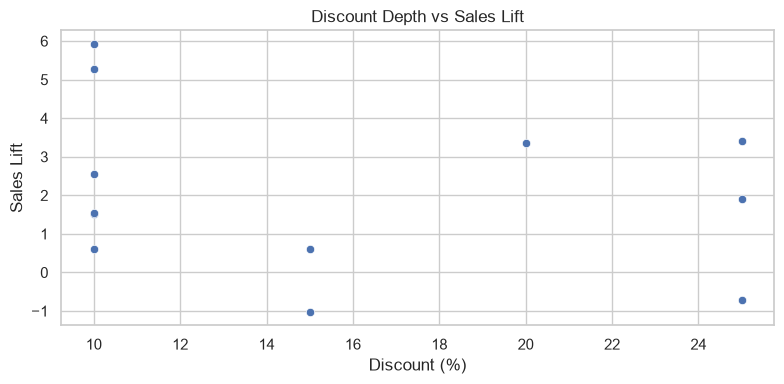

In [25]:
# YOUR CODE HERE
# Hint: your question, your code
# Discount depth vs sales lift
promo_data = d["promotions"].merge( promo_results, on="promo_id")
print(promo_data[["promo_id", "discount_pct", "lift", "p_value"]])

plt.figure(figsize=(8, 4))
sns.scatterplot(data=promo_data, x="discount_pct", y="lift")
plt.title("Discount Depth vs Sales Lift")
plt.xlabel("Discount (%)")
plt.ylabel("Sales Lift")
plt.tight_layout()
plt.show()

### The CLI
Run it from a terminal in the folder that contains `freshmart/` and `data/`:

```
python -m freshmart report --store 4
python -m freshmart report --store 2 --month 6
```
Paste the output of the first command in the cell below as a comment.

In [ ]:
# python -m freshmart report --store 4
# (paste output here)
Top Margin Products:
top_margin took 0.0167 seconds
     product_id product_name    margin
45         1046      GROC-14  84889.08
92         1094      BEVE-12  61546.17
74         1076      SNAC-14  34554.74
48         1049      GROC-17  34002.00
108        1110      PERS-12  31964.10
43         1044      GROC-12  30344.51
107        1109      PERS-11  27485.71
16         1017      DAIR-17  26336.23
52         1053      GROC-21  21574.10
116        1118      HOUS-08  20985.36

Store Productivity:
store_productivity took 0.0240 seconds
   store_id    revenue     margin  receipts               store_name  floor_area_sqft  margin_per_sq_ft
0         1  1717477.0  467755.45      6476  FreshMart Banjara Hills             4200        111.370345
1         2  2491452.9  668620.50      9422     FreshMart Kukatpally             6800         98.326544
2         3  1917148.0  519816.63      7275   FreshMart Secunderabad             5100        101.924829
3         4  2855218.1  770276.59     11119     FreshMart Gachibowli             7500        102.703545
4         5  1465164.0  398615.48      5805   FreshMart Dilsukhnagar             3900        102.209097

Stock-outs:
stockouts took 1.7108 seconds
    product_id  store_id      rate  max_zero_run  avg_daily_revenue
0         1032         3  2.419890             6         152.237569
1         1044         1  1.728022             7         212.500000
2         1044         3  1.626374            10         203.571429
3         1044         4  2.180822             6         271.753425
4         1046         2  2.030137             6         572.960000
5         1046         3  1.583562             7         450.400000
6         1046         4  2.223140             6         600.892562
7         1073         1  1.576177             8          31.689751
8         1073         3  1.871233             8          39.419178
9         1073         5  1.516484             9          30.582418
10        1076         1  1.870879             7         119.642857
11        1076         2  2.504110             9         160.800000
12        1076         4  3.451791             6         215.931956
13        1076         5  1.522099             7          96.613260
14        1077         1  2.613699            12          79.605479
15        1077         5  2.530220             7          78.153846
16        1094         2  7.843836             8         377.249315
17        1113         2  1.666667             7         162.415978
18        1113         4  2.036011             7         202.796122

### Recommendation (120–180 words, to the owner)
Finding → number → action for 2026 → one thing you'd check with more data.

> *Your paragraph here.*

FreshMart’s analysis shows that some products and stores are making more profit than others. Store 4 made about ₹7.7 lakh in margin, and GROC-14 was one of its top-performing products with a margin of ₹84,889. We also found some products staying out of stock for 6–12 days, which could mean lost sales. For 2026, FreshMart should keep popular and high-profit products well stocked and focus on promotions that actually increase sales. The stores should also use their space wisely by giving more space to profitable products. With more data, I would check which products customers usually buy together. This could help FreshMart plan stock better, place products more effectively, and reduce lost sales.

### Cliffhanger
Q3 shows every category has a weekly rhythm and a festival peak. The owner asks: "So what will GROC-14 sell in January?" — Module 19.